In [48]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [49]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 5.1' / 'summary.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    # print(data)

/Users/williamhampshire/Desktop/pycharm/research_project


In [50]:
# aim is to plot the mode energies and separation against: period, thickness, filling
from icecream import ic
import time


# Lists to store filtered data
periods = []
thicknesses = []
fillings = []
mean_energy = []
diff_energy = []

count_length_not_2 = 0
count_not_correct_form = 0
count_correct_form = 0
total = 0

# print(data)

# Extract data
for key, value in data.items():
    total += 1
    #print(value)
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    print(key_parts)
    
    
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    filling = float(key_parts[2].split('=')[1])
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        count_length_not_2 += 1
        # print("Len not 2")
        continue
    
   

    temp_vertices:list = []
    temp_thickness:float = None
    temp_period:float = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    temp_filling = float(filling)
    # ic(temp_filling)
    
    # Only consider entries with R2 > 0.6
    for i,key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if (abs(R2) > 0.6) and (R2 != 1.0):
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append([key,vertex])
            #print([key,vertex])
            
    if len(temp_vertices) == 2:
        vtc1 = temp_vertices[0]
        vtc2 = temp_vertices[1]
        if (int(vtc1[0]) % 2) > (int(vtc2[0]) % 2):
            # if the first one is odd and second is even
            count_not_correct_form += 1
            print("Incorrect form")
            continue
            
        elif (int(vtc1[0]) % 2) < (int(vtc2[0]) % 2):
            vtcs: list = [float(vtc1[1]), float(vtc2[1])]
            # ic(vtcs, temp_filling, temp_period, temp_thickness)
            mean_energy.append(np.mean(vtcs))
            # print(temp_vertices, np.diff(vtcs))
            diff_energy.append(float(np.diff(vtcs)[0]))
            print(vtcs, np.mean(vtcs), np.diff(vtcs)[0])
            
            periods.append(temp_period)
            thicknesses.append(temp_thickness)
            fillings.append(temp_filling)
            count_correct_form += 1
            # print(key)
            # print(value)
            print(f"CORRECT FORM - {temp_filling}")
        else:
            count_not_correct_form += 1
            print("Incorrect form")
            continue
    else:
        count_length_not_2 += 1
        # print("Len not 2")
        continue
        
print(fillings)
print("-------")

df_filtered = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])
df_filtered['period'] = periods
df_filtered['thickness'] = thicknesses
df_filtered['filling'] = fillings
df_filtered['mean_energy'] = mean_energy
df_filtered['diff_energy'] = diff_energy

df_filtered.head()
df_filtered.describe()


['t=20.0nm', 'Λ=340nm', 'FF=0.70', 'N=75']
Incorrect form
['t=20.0nm', 'Λ=360nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=380nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=400nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=400nm', 'FF=0.74', 'N=75']
['t=20.0nm', 'Λ=420nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=420nm', 'FF=0.74', 'N=75']
['t=20.0nm', 'Λ=440nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=440nm', 'FF=0.74', 'N=75']
['t=20.0nm', 'Λ=460nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=460nm', 'FF=0.74', 'N=75']
['t=20.0nm', 'Λ=460nm', 'FF=0.78', 'N=75']
[1.7326019464389133, 1.5865852758443486] 1.659593611141631 -0.1460166705945647
CORRECT FORM - 0.78
['t=20.0nm', 'Λ=480nm', 'FF=0.70', 'N=75']
['t=20.0nm', 'Λ=480nm', 'FF=0.74', 'N=75']
[1.6917437975041076, 1.5601128935423476] 1.6259283455232276 -0.13163090396176003
CORRECT FORM - 0.74
['t=20.0nm', 'Λ=480nm', 'FF=0.78', 'N=75']
[1.6785365787176358, 1.5489032066636856] 1.6137198926906606 -0.1296333720539502
CORRECT FORM - 0.78
['t=20.0nm', 'Λ=500nm', 'FF=0.74', 'N=75

,period,thickness,filling,mean_energy,diff_energy
count,56.000000,56.000000,56.000000,56.000000,56.000000
mean,525.714286,52.321429,0.744286,1.515292,0.271612
std,59.294554,25.440917,0.039398,0.083543,0.263293
min,400.000000,20.000000,0.700000,1.332252,-0.146017
25%,480.000000,20.000000,0.700000,1.438970,-0.074301
50%,530.000000,50.000000,0.740000,1.523210,0.414376
75%,580.000000,80.000000,0.780000,1.588281,0.439552
max,600.000000,90.000000,0.820000,1.659594,0.585131


In [51]:
counts = pd.Series([count_length_not_2, count_not_correct_form, count_correct_form, total], index=['len not 2', 'not correct form', 'correct form', 'total'])
print(df_filtered.shape)
counts

(56, 5)


len not 2            57
not correct form     84
correct form         56
total               197
dtype: int64

In [52]:

# title = 'Mode separation energy as function of thickness'

# Lists to store filtered data
df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])

# Assuming 'data' is your dictionary with the necessary data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    ff = float(key_parts[2].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
    temp_vertices = []

    temp_period = float(period)
    temp_thickness = float(thickness)
    temp_filling = float(ff)
    
    # Only consider entries with R2 > 0.6
    for i, key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to temporary list
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        # Calculate mean energy and difference in energy
        mean_energy_value = np.mean(temp_vertices)
        diff_energy_value = np.diff(temp_vertices)[0]
        
        # Create a new row as a dictionary
        new_row = {
            'period': temp_period,
            'thickness': temp_thickness,
            'filling': temp_filling,
            'mean_energy': mean_energy_value,
            'diff_energy': diff_energy_value
        }
        
        # Append the new row to the DataFrame
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df['diff_energy']=df['diff_energy'].apply(np.abs)

filtered:bool = False
if filtered:
    df = df_filtered.copy()
else:
    pass
    # ie df = df

# Convert DataFrame columns to numpy arrays if needed
periods = df['period'].to_numpy()
thicknesses = df['thickness'].to_numpy()
filling = df['filling'].to_numpy()
diff_energy = df['diff_energy'].to_numpy()
mean_energy = df['mean_energy'].to_numpy()

df.head(5)


/var/folders/pk/mrkz02nn7qd5bc8rndd2bd8c0000gn/T/ipykernel_12293/810435835.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


,period,thickness,filling,mean_energy,diff_energy
0,340.0,20.0,0.70,1.639055,0.419038
1,460.0,20.0,0.78,1.659594,0.146017
2,480.0,20.0,0.74,1.625928,0.131631
3,480.0,20.0,0.78,1.613720,0.129633
4,500.0,20.0,0.74,1.588148,0.129917


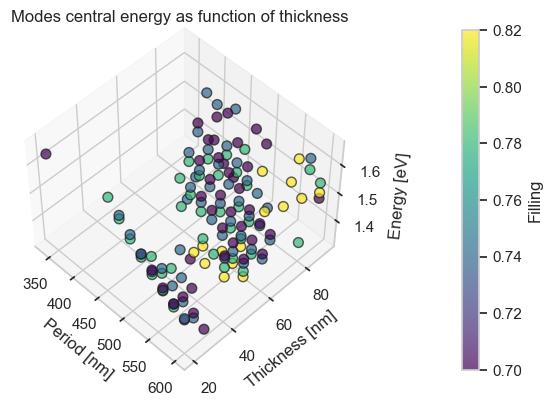

<Figure size 640x480 with 0 Axes>

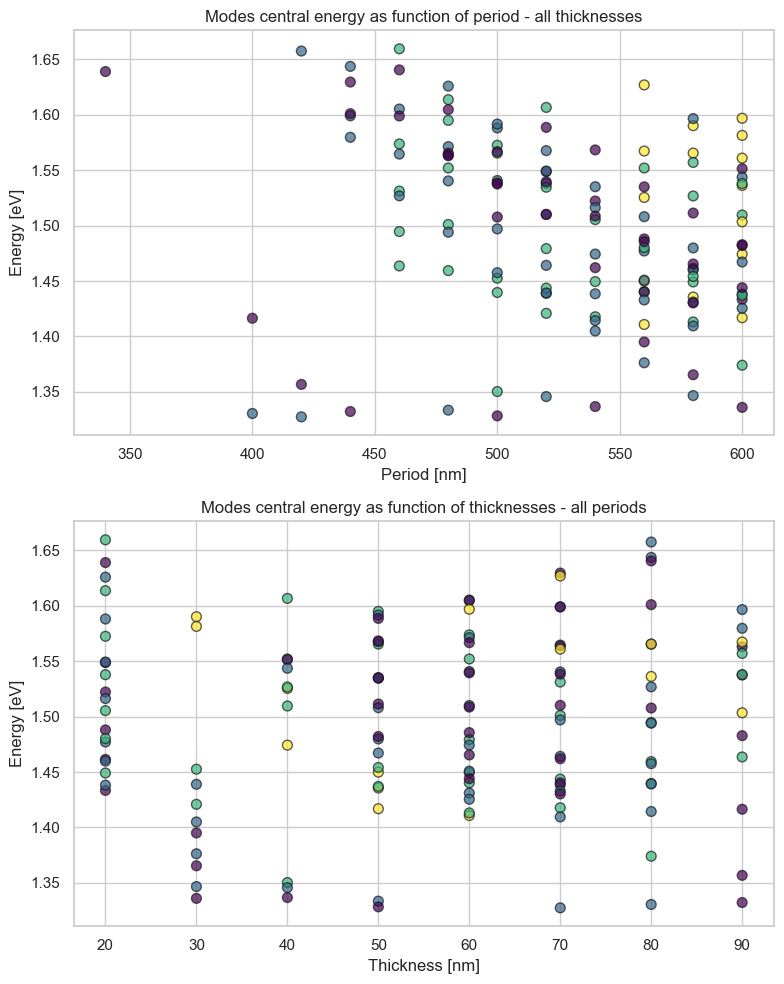

In [53]:
title = 'Modes central energy as function of thickness'

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
#ax1.invert_yaxis()
plt.subplots_adjust(right=2)
plt.show()
plt.clf()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes central energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes central energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

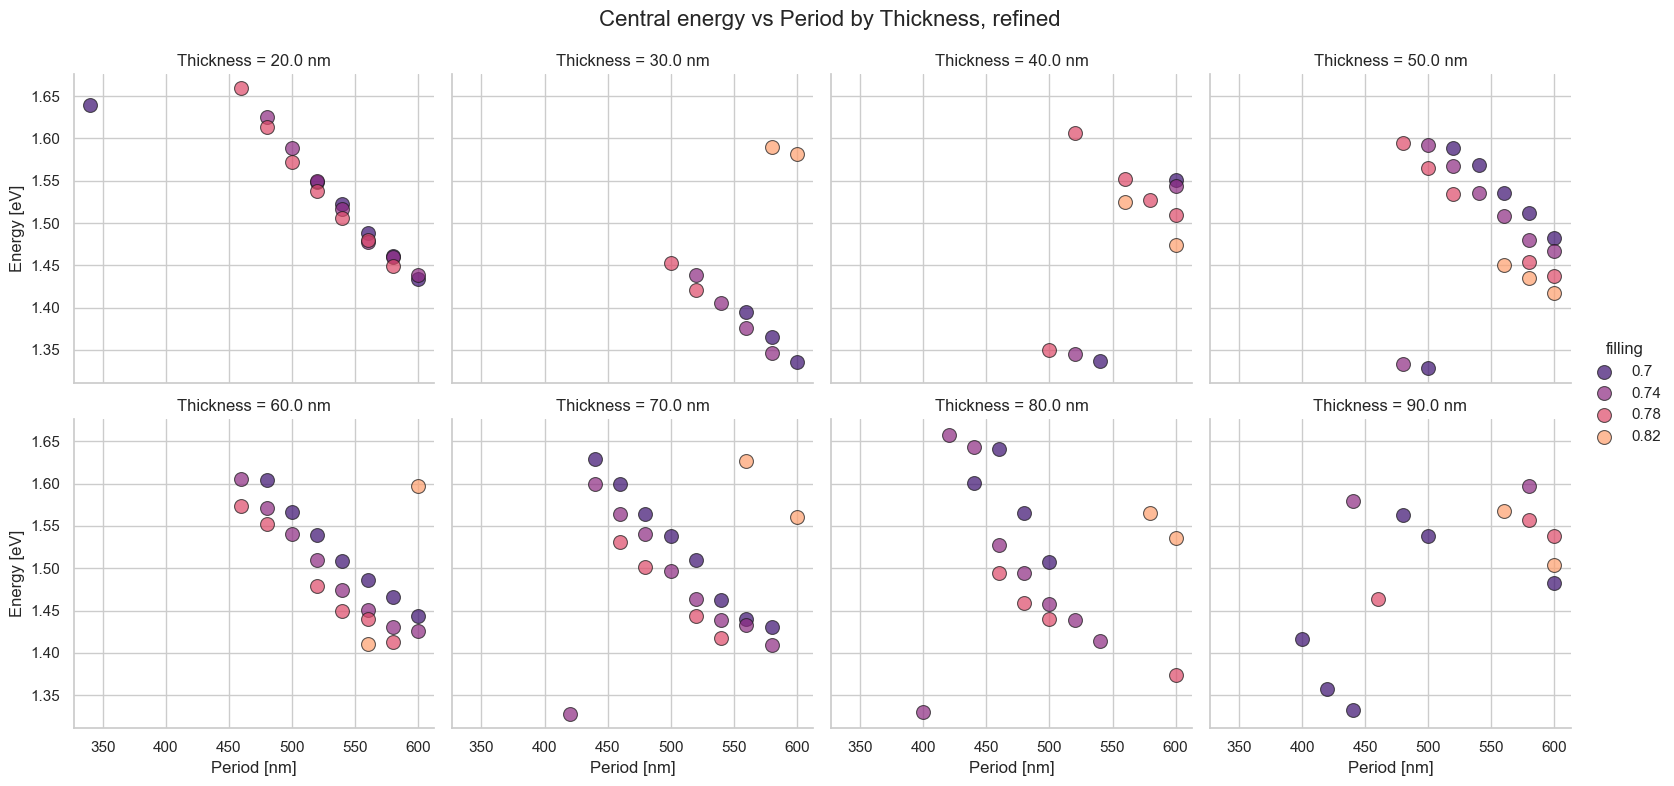

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=4, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Central energy vs Period by Thickness, refined', fontsize=16)

savepath = cwd / 'mode_fitting_viz'
savepath.mkdir(exist_ok=True)
plt.savefig(savepath/'central_energy_period_refined.png', dpi=300)

plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
# fig2 = plt.figure(figsize=(15, 10))
# g2 = sns.FacetGrid(
#     data=df,
#     col="period", 
#     col_wrap=4, 
#     height=4, 
#     hue="filling", 
#     palette="magma"
# )
# g2.map_dataframe(
#     sns.scatterplot, 
#     x="thickness", 
#     y="mean_energy", 
#     edgecolor='k', 
#     s=100, 
#     alpha=0.7
# )
# g2.set_axis_labels(t_lab, e_lab)
# g2.set_titles(col_template="Period = {col_name} nm")
# g2.add_legend()
# 
# # Display the Energy vs Thickness plot grid
# plt.subplots_adjust(top=0.9)
# g2.fig.suptitle('Central energy vs Thickness (by Period)', fontsize=16)
# 
# 
# plt.show()


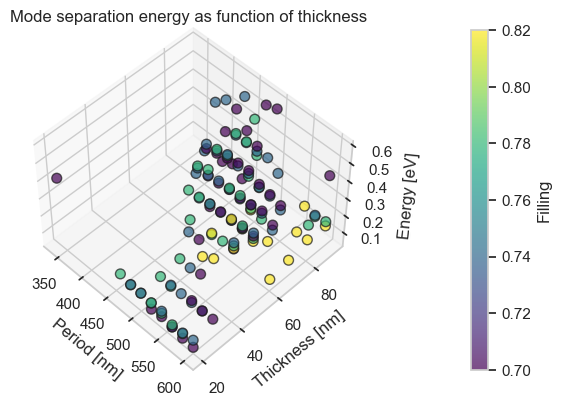

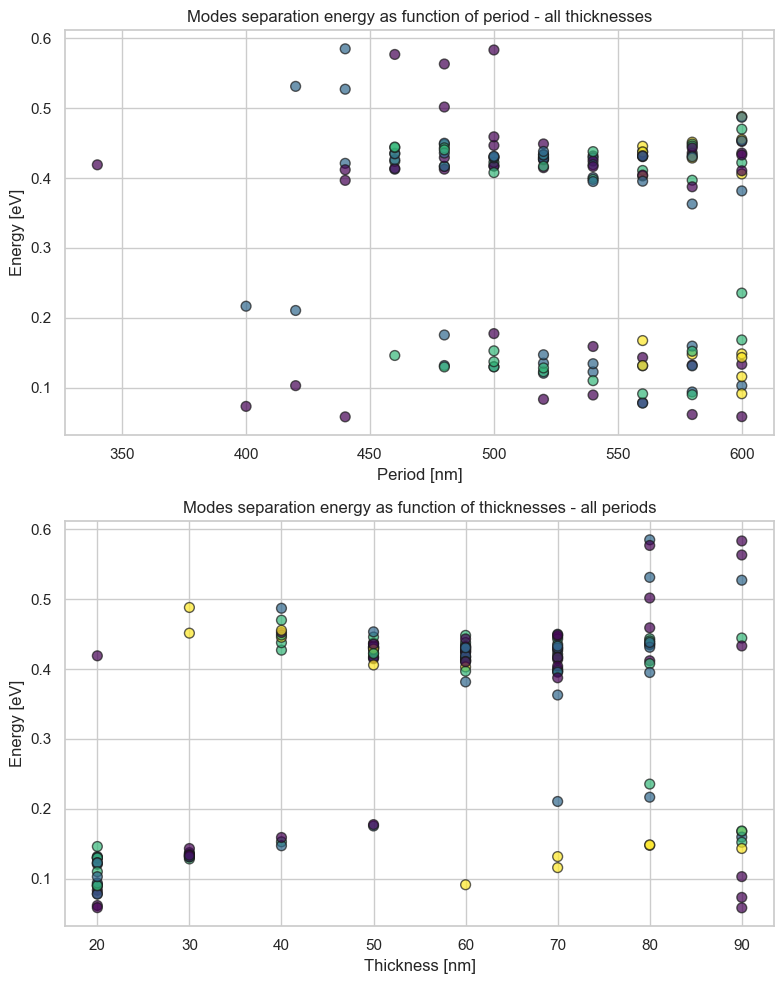

In [55]:

title = 'Mode separation energy as function of thickness'
#  = 'Modes central energy as function of thickness'


fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
#ax1.invert_yaxis()
plt.subplots_adjust(right=2)
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes separation energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes separation energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

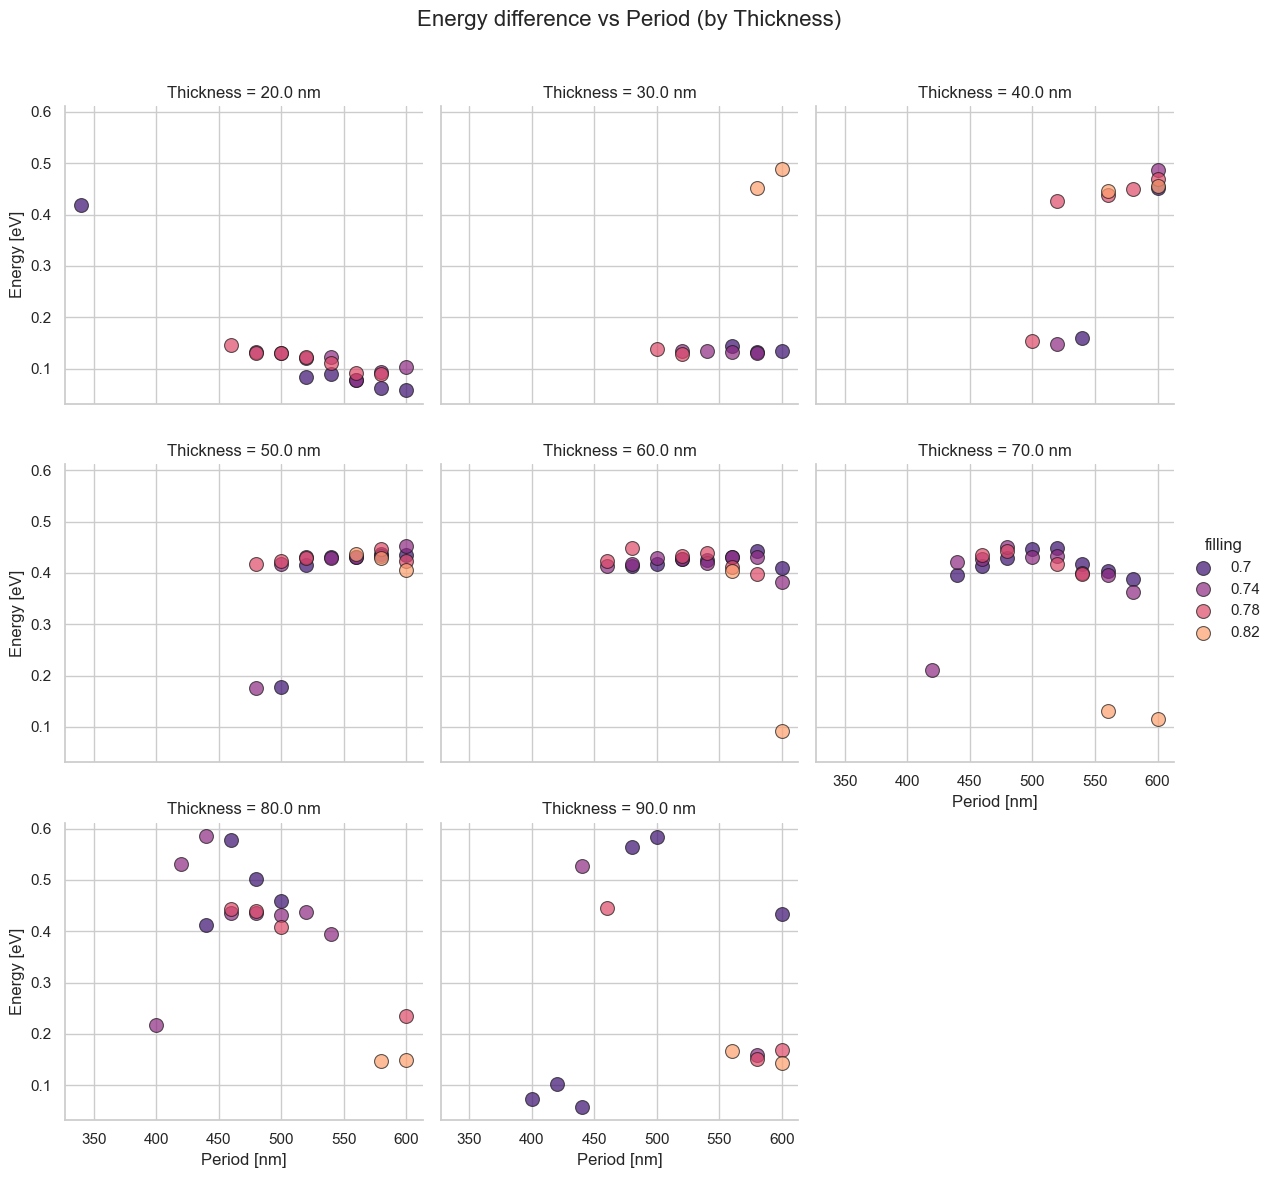

<Figure size 1500x1000 with 0 Axes>

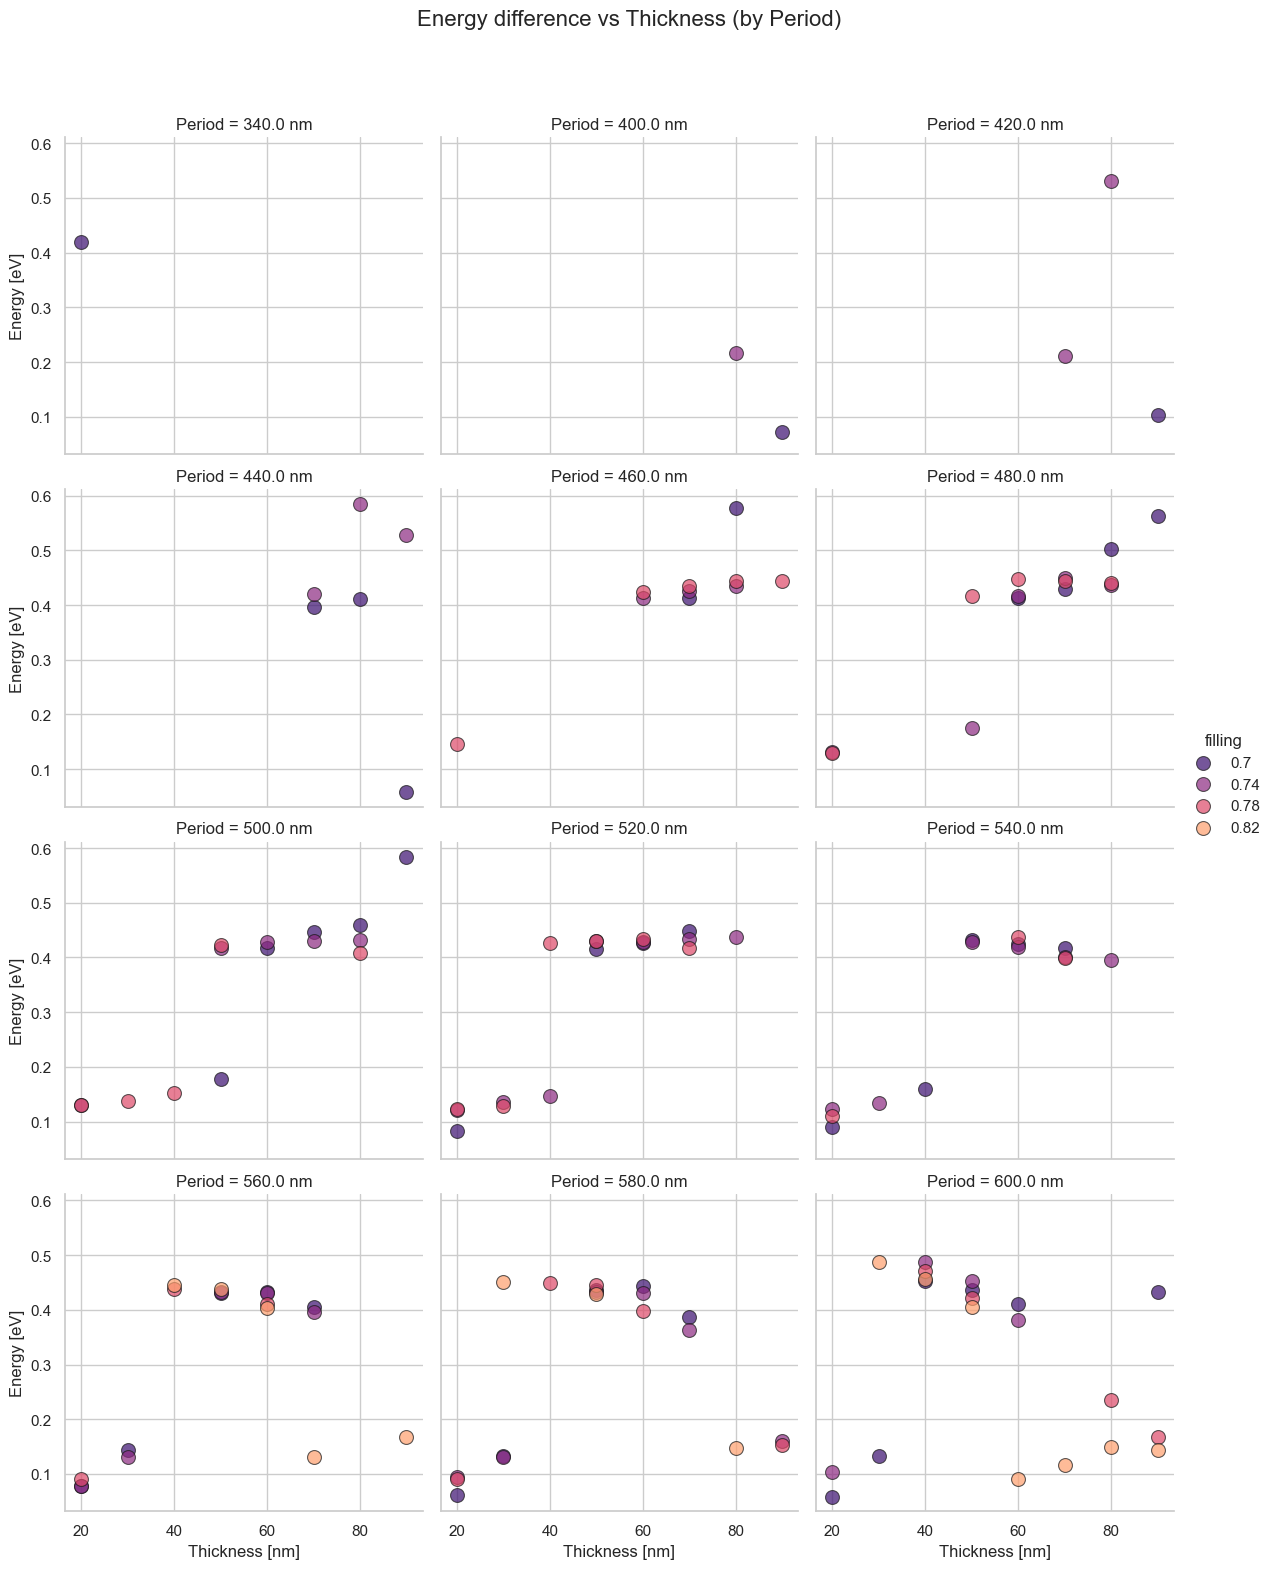

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Energy difference vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Energy difference vs Thickness (by Period)', fontsize=16)
plt.show()


In [57]:
print()